# Линейная регрессия

In [40]:
import pandas as pd
import scipy.stats
import matplotlib.pyplot as plt
import pyodbc
import seaborn as sns
import json
import pyarrow
import gzip
from lxml import objectify
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

### Reading the data in a dataframe

In [41]:
# csv
df = pd.read_csv("ToyotaCorolla.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 39 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Id                 1436 non-null   int64
 1   Model              1436 non-null   str  
 2   Price              1436 non-null   int64
 3   Age_08_04          1436 non-null   int64
 4   Mfg_Month          1436 non-null   int64
 5   Mfg_Year           1436 non-null   int64
 6   KM                 1436 non-null   int64
 7   Fuel_Type          1436 non-null   str  
 8   HP                 1436 non-null   int64
 9   Met_Color          1436 non-null   int64
 10  Color              1436 non-null   str  
 11  Automatic          1436 non-null   int64
 12  CC                 1436 non-null   int64
 13  Doors              1436 non-null   int64
 14  Cylinders          1436 non-null   int64
 15  Gears              1436 non-null   int64
 16  Quarterly_Tax      1436 non-null   int64
 17  Weight             1436 n

## <u> EDA


In [42]:
# get the name of the columns in the dataframe
print("The columns are:", list(df.columns))

The columns are: ['Id', 'Model', 'Price', 'Age_08_04', 'Mfg_Month', 'Mfg_Year', 'KM', 'Fuel_Type', 'HP', 'Met_Color', 'Color', 'Automatic', 'CC', 'Doors', 'Cylinders', 'Gears', 'Quarterly_Tax', 'Weight', 'Mfr_Guarantee', 'BOVAG_Guarantee', 'Guarantee_Period', 'ABS', 'Airbag_1', 'Airbag_2', 'Airco', 'Automatic_airco', 'Boardcomputer', 'CD_Player', 'Central_Lock', 'Powered_Windows', 'Power_Steering', 'Radio', 'Mistlamps', 'Sport_Model', 'Backseat_Divider', 'Metallic_Rim', 'Radio_cassette', 'Parking_Assistant', 'Tow_Bar']


In [43]:
# get the number of columns in the dataframe
print("The number of columns is:", len(df.columns))

The number of columns is: 39


In [44]:
# rename columns
df = df.rename(columns={'oldX':'newX', 'oldY':'newY'})

In [45]:
# select the value in column X at index i
print("The value in column X at index i is:", df["Model"][1])

The value in column X at index i is: TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors


In [46]:
# print the dataframes's first 5 rows
print("The first 5 rows are:\n")
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print(df.head(5))

The first 5 rows are:

   Id                                          Model  Price  Age_08_04  \
0   1  TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors  13500         23   
1   2  TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors  13750         23   
2   3  TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors  13950         24   
3   4  TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors  14950         26   
4   5    TOYOTA Corolla 2.0 D4D HATCHB SOL 2/3-Doors  13750         30   

   Mfg_Month  Mfg_Year     KM Fuel_Type  HP  Met_Color   Color  Automatic  \
0         10      2002  46986    Diesel  90          1    Blue          0   
1         10      2002  72937    Diesel  90          1  Silver          0   
2          9      2002  41711    Diesel  90          1    Blue          0   
3          7      2002  48000    Diesel  90          0   Black          0   
4          3      2002  38500    Diesel  90          0   Black          0   

     CC  Doors  Cylinders  Gears  Quarterly_Tax  Weight  Mfr_Guarante

In [47]:
# print the dataframes's last 5 rows
print("The first 5 rows are:\n")
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print(df.tail(5))

The first 5 rows are:

        Id                                              Model  Price  \
1431  1438         TOYOTA Corolla 1.3 16V HATCHB G6 2/3-Doors   7500   
1432  1439  TOYOTA Corolla 1.3 16V HATCHB LINEA TERRA 2/3-...  10845   
1433  1440  TOYOTA Corolla 1.3 16V HATCHB LINEA TERRA 2/3-...   8500   
1434  1441  TOYOTA Corolla 1.3 16V HATCHB LINEA TERRA 2/3-...   7250   
1435  1442        TOYOTA Corolla 1.6 LB LINEA TERRA 4/5-Doors   6950   

      Age_08_04  Mfg_Month  Mfg_Year     KM Fuel_Type   HP  Met_Color  Color  \
1431         69         12      1998  20544    Petrol   86          1   Blue   
1432         72          9      1998  19000    Petrol   86          0   Grey   
1433         71         10      1998  17016    Petrol   86          0   Blue   
1434         70         11      1998  16916    Petrol   86          1   Grey   
1435         76          5      1998      1    Petrol  110          0  Green   

      Automatic    CC  Doors  Cylinders  Gears  Quarterly_Tax  

In [48]:
# print the distinct values in variable X
print("The distinct values of variable X are:", df['Model'].unique())

The distinct values of variable X are: <ArrowStringArray>
[              'TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors',
                 'TOYOTA Corolla 2.0 D4D HATCHB SOL 2/3-Doors',
               'TOYOTA Corolla 2.0 D4D 90 3DR TERRA 2/3-Doors',
                 'TOYOTA Corolla 1800 T SPORT VVT I 2/3-Doors',
                 'TOYOTA Corolla 1.9 D HATCHB TERRA 2/3-Doors',
           'TOYOTA Corolla 1.8 VVTL-i T-Sport 3-Drs 2/3-Doors',
      'TOYOTA Corolla 1.8 16V VVTLI 3DR T SPORT BNS 2/3-Doors',
          'TOYOTA Corolla 1.8 16V VVTLI 3DR T SPORT 2/3-Doors',
       'TOYOTA Corolla 1.6 VVTI Linea Terra Comfort 2/3-Doors',
                      'TOYOTA Corolla 1.6 16v L.SOL 2/3-Doors',
 ...
                'TOYOTA Corolla 1.6 VVTi Linea Luna 2/3-Doors',
          'TOYOTA Corolla 1.3 16V Linea Terra Liftb 2/3-Doors',
                'TOYOTA Corolla 1.3 HB LINEA TERRA AUT Anders',
 'TOYOTA Corolla LIFTBACK 1.3i Linea Terra Liftback 4/5-Doors',
                             'TOYOTA Coro

In [49]:
# print the value counts in variable X
print("The number of occurences of each value in variable X are:", df['Model'].value_counts())

The number of occurences of each value in variable X are: Model
TOYOTA Corolla 1.6 16V HATCHB LINEA TERRA 2/3-Doors    109
TOYOTA Corolla 1.3 16V HATCHB LINEA TERRA 2/3-Doors     84
TOYOTA Corolla 1.6 16V LIFTB LINEA LUNA 4/5-Doors       80
TOYOTA Corolla 1.6 16V LIFTB LINEA TERRA 4/5-Doors      71
TOYOTA Corolla 1.4 16V VVT I HATCHB TERRA 2/3-Doors     54
                                                      ... 
TOYOTA Corolla 1.6 SDN LINEA TERRA AUT 4/5-Doors         1
TOYOTA Corolla 1.3 HB LINEA TERRA AUT 2/3-Doors          1
TOYOTA Corolla 1.3 Linea Terra sedan 4/5-Doors           1
TOYOTA Corolla 1.6 Lin.Terra Aut. 2/3-Doors              1
TOYOTA Corolla 1.3 Linea Terra 4/5-Doors                 1
Name: count, Length: 319, dtype: int64


In [50]:
print("The number of records is:", len(df))

The number of records is: 1436


In [51]:
print("The number of missing values per column is:")
print(df.isna().sum())

The number of missing values per column is:
Id                   0
Model                0
Price                0
Age_08_04            0
Mfg_Month            0
Mfg_Year             0
KM                   0
Fuel_Type            0
HP                   0
Met_Color            0
Color                0
Automatic            0
CC                   0
Doors                0
Cylinders            0
Gears                0
Quarterly_Tax        0
Weight               0
Mfr_Guarantee        0
BOVAG_Guarantee      0
Guarantee_Period     0
ABS                  0
Airbag_1             0
Airbag_2             0
Airco                0
Automatic_airco      0
Boardcomputer        0
CD_Player            0
Central_Lock         0
Powered_Windows      0
Power_Steering       0
Radio                0
Mistlamps            0
Sport_Model          0
Backseat_Divider     0
Metallic_Rim         0
Radio_cassette       0
Parking_Assistant    0
Tow_Bar              0
dtype: int64


In [52]:
# create a copy of df
df_ = df.copy()

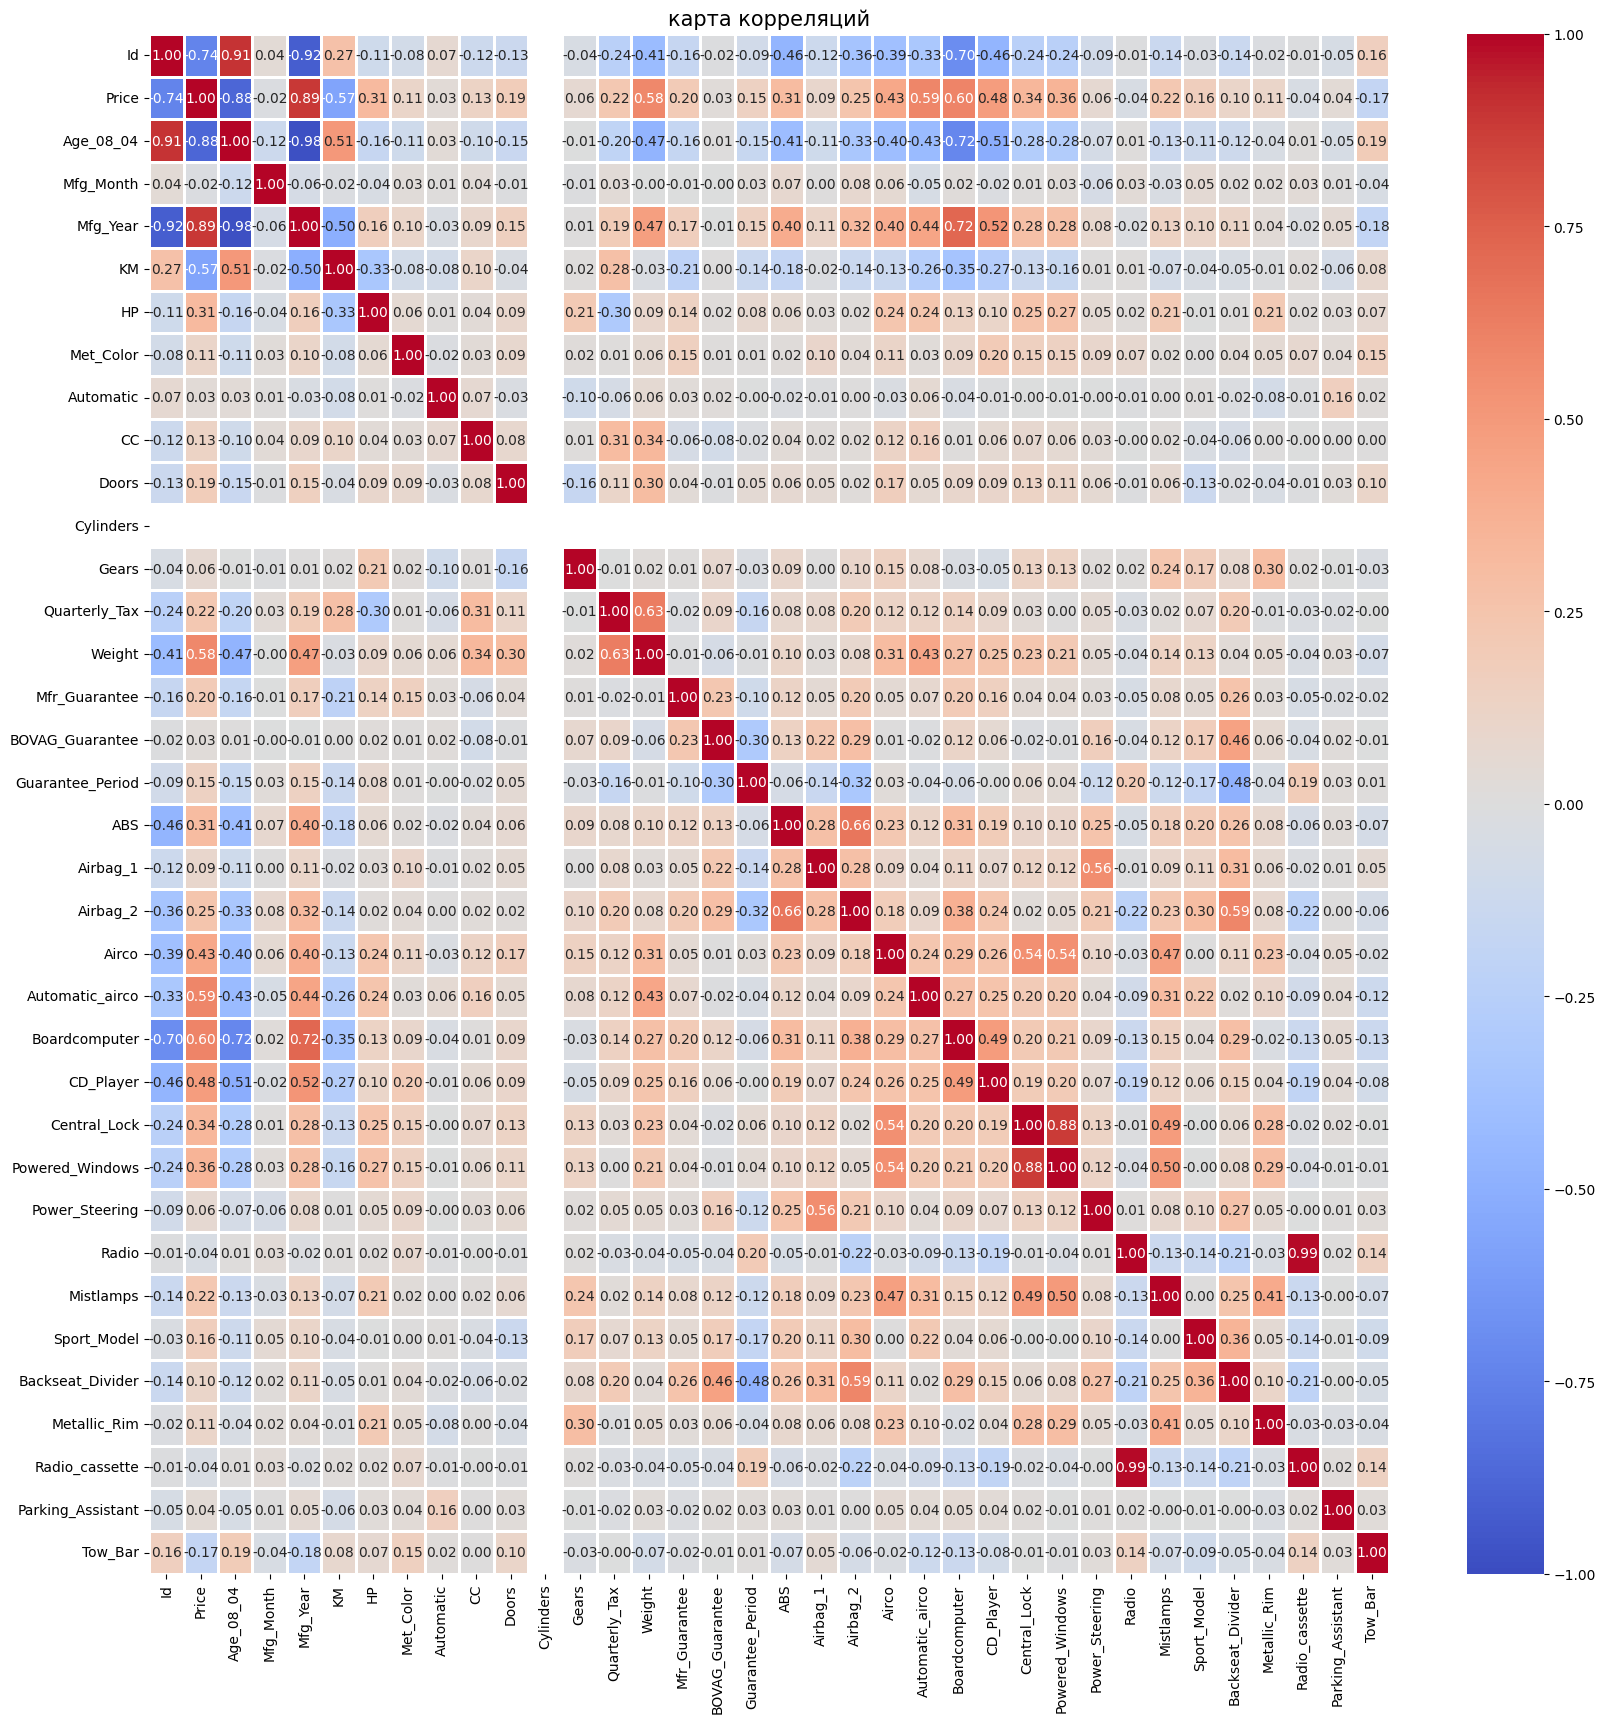

In [53]:
plt.figure(figsize=(20, 20))

numeric_df = df.select_dtypes(include=['number'])

corr_matrix = numeric_df.corr()

sns.heatmap(
    corr_matrix, 
    annot=True,        
    cmap='coolwarm',   
    fmt='.2f',           
    linewidths=1,       
    vmin=-1, vmax=1    
)

plt.title('карта корреляций', fontsize=15)
plt.show()

In [54]:
print(df['Cylinders'].unique())

[4]


так как у всех одинаковое колличество цилиндров, то этот столбец можно убрать из датафрейма

In [55]:
df = df.drop('Cylinders', axis=1)

уберем пару столбцов

In [56]:
df = df.drop(['Id',], axis=1)
df = pd.get_dummies(df, columns=['Fuel_Type', 'Color'], drop_first=True)


модель может сильно влиять на стоимость авто. я бы для этого в обучающих данных кодировал стоимость новой модели при выпуске с учетом инфляции сегодня, но так как данных много я заменю на среднюю стоимость для каждой модели

In [57]:
train, test = train_test_split(df, test_size=0.2, random_state=42)

model_means = train.groupby('Model')['Price'].mean()

global_mean = train['Price'].mean()

train['Model_Encoded'] = train['Model'].map(model_means)

test['Model_Encoded'] = test['Model'].map(model_means).fillna(global_mean)

X_train = train.drop(['Price', 'Model'], axis=1)
y_train = train['Price']

X_test = test.drop(['Price', 'Model'], axis=1)
y_test = test['Price']
X_train.head()



,Age_08_04,Mfg_Month,Mfg_Year,KM,HP,Met_Color,Automatic,CC,Doors,Gears,...,Color_Black,Color_Blue,Color_Green,Color_Grey,Color_Red,Color_Silver,Color_Violet,Color_White,Color_Yellow,Model_Encoded
899,62,7,1999,59295,86,0,0,1300,5,5,...,False,False,False,False,True,False,False,False,False,8434.516129
881,68,1,1999,61568,110,1,0,1600,4,5,...,False,False,False,False,False,True,False,False,False,8353.750000
310,40,5,2001,38653,110,1,0,1600,5,5,...,False,False,True,False,False,False,False,False,False,12175.555556
1145,75,6,1998,101855,110,1,0,1600,5,5,...,False,False,False,True,False,False,False,False,False,8750.272727
31,22,11,2002,35199,97,1,0,1400,3,5,...,False,True,False,False,False,False,False,False,False,15918.181818


In [58]:
y_train.head()

899      9500
881      9795
310     12950
1145     6450
31      15750
Name: Price, dtype: int64

In [59]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


model = LinearRegression()

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Средняя ошибка (MAE): {mae:.2f} €")
print(f"Точность (R2 Score): {r2:.4f}")


# Создаем таблицу коэффициентов для наглядности
coefficients = pd.DataFrame(model.coef_, X_train.columns, columns=['Coefficient'])
print(coefficients.sort_values(by='Coefficient', ascending=False))

Средняя ошибка (MAE): 914.95 €
Точность (R2 Score): 0.8453
                   Coefficient
Model_Encoded      2090.711487
Mfg_Year            559.993814
Weight              172.101747
Automatic_airco     167.519595
Quarterly_Tax       155.655090
Fuel_Type_Diesel    129.108611
Mfr_Guarantee       122.676653
BOVAG_Guarantee     113.585854
Airco               108.959851
Powered_Windows     103.143098
Fuel_Type_Petrol     93.509083
HP                   78.434089
Guarantee_Period     35.443202
Metallic_Rim         34.898567
Automatic            34.702325
Airbag_2             33.263284
CD_Player            30.952660
Power_Steering       28.192441
Doors                14.440117
Radio                12.104418
Gears                 8.209151
Color_Yellow          1.207784
Met_Color           -15.504744
Mistlamps           -17.161136
Airbag_1            -17.854430
CC                  -19.288556
Sport_Model         -20.711095
Tow_Bar             -34.911014
Parking_Assistant   -35.640093
Color_Viole

In [ ]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import r2_score, mean_absolute_error

# Считаем 25-й и 75-й перцентили (Q1 и Q3)
Q1 = y_train.quantile(0.25)
Q3 = y_train.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

mask = (y_train >= lower_bound) & (y_train <= upper_bound)

X_train_clean = X_train_scaled[mask.values]
y_train_clean = y_train[mask]

print(f"Строк до очистки выбросов: {len(y_train)}")
print(f"Строк после очистки: {len(y_train_clean)}")
print("-" * 30)


ridge_model = Ridge(alpha=100.0)
ridge_model.fit(X_train_clean, y_train_clean)
y_pred_ridge = ridge_model.predict(X_test_scaled)

print("=== Ridge Regression (L2) ===")
print(f"MAE: {mean_absolute_error(y_test, y_pred_ridge):.2f} €")
print(f"R2 Score: {r2_score(y_test, y_pred_ridge):.4f}")
print("-" * 30)


lasso_model = Lasso(alpha=100.0)
lasso_model.fit(X_train_clean, y_train_clean)
y_pred_lasso = lasso_model.predict(X_test_scaled)

print("=== Lasso Regression (L1) ===")
print(f"MAE: {mean_absolute_error(y_test, y_pred_lasso):.2f} €")
print(f"R2 Score: {r2_score(y_test, y_pred_lasso):.4f}")




Строк до очистки выбросов: 1148
Строк после очистки: 1058
------------------------------
=== Ridge Regression (L2) ===
MAE: 916.78 €
R2 Score: 0.8442
------------------------------
=== Lasso Regression (L1) ===
MAE: 1028.44 €
R2 Score: 0.7895
